# Reduzindo o Detalhe de Mapas de Zona de Entrega para Painéis de Logística Rápidos com PROC GREDUCE

## Resumo Executivo

Uma transportadora regional de encomendas armazena os limites de seus territórios de atendimento como contornos de polígonos densos, e os painéis de planejamento de rotas os redesenham lentamente. Este notebook sintetiza as coordenadas de limite para quatro zonas de entrega, usa **PROC GREDUCE** para marcar cada vértice de limite com um nível `DENSITY`, e então renderiza um mapa coroplético de entrega no prazo com **PROC GMAP** em um nível de detalhe reduzido para que o mapa seja desenhado mais rápido enquanto cada zona permanece reconhecível.

O GREDUCE classificou os 96 pontos de limite em três níveis: 10 pontos em `DENSITY=0`, 44 em `DENSITY=2`, e 42 em `DENSITY=3`. Manter apenas o nível grosseiro (`DENSITY <= 2`) reduz o mapa de 96 vértices para 54 — cerca de uma redução de 44% — mas as quatro zonas permanecem claramente identificáveis na comparação lado a lado abaixo.

## Fontes de Dados

Todos os dados são gerados inline pelas etapas DATA abaixo — sem arquivos externos ou acesso à rede.

| Dataset | Linhas | Variáveis-chave | Descrição |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zonas x 24 vértices) | `zone` (ID), `x`, `y` | Coordenadas sintéticas de limite de polígono fechado para quatro zonas de serviço de entrega, cada uma uma elipse com leve distorção traçada por 24 vértices para que a redução de densidade tenha algo para afinar. |
| `reducedmap` | 96 | adiciona `density` | Saída do PROC GREDUCE: os pontos de limite marcados com um nível `DENSITY` (aqui 0, 2 ou 3) para renderização seletiva. |
| `coarsemap` | 54 | subconjunto de `reducedmap` | O subconjunto `DENSITY <= 2` — o nível grosseiro de renderização rápida usado para o mapa do painel de detalhe reduzido. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Uma linha de resposta por zona: percentual sintético de entrega no prazo e volume diário de pacotes, unida ao mapa para o coroplético. |

> **Nota sobre o tamanho da amostra.** Este ambiente é executado sem licença, então cada etapa DATA é limitada a 100 observações de saída. O mapa é dimensionado para 4 zonas x 24 vértices = 96 pontos para que todo o território caiba dentro desse limite; uma instalação licenciada traçaria centenas de vértices por zona, onde o GREDUCE compensa ainda mais.

# Reduzindo o Detalhe de Mapas de Zona de Entrega com PROC GREDUCE

Operadores de logística visualizam o desempenho em mapas de seus **territórios de atendimento** — as zonas geográficas pelas quais um depósito é responsável. Esses limites de zona são frequentemente capturados em resolução de levantamento: muitos vértices por polígono. Quando um painel de planejamento de rotas redesenha várias zonas de uma vez, todo esse detalhe de vértices torna a renderização lenta sem agregar valor de decisão no zoom do painel.

**PROC GREDUCE** resolve isso. Ele examina cada polígono e marca cada ponto de limite com um nível `DENSITY`, onde 0 marca os pontos que definem a forma essencial e níveis mais altos marcam detalhe progressivamente mais fino. Mais adiante, você seleciona um nível com `WHERE density <= n` para desenhar um mapa de detalhe reduzido que é renderizado rápido enquanto cada zona permanece reconhecível.

Neste notebook nós:
1. Sintetizamos os contornos de limite para quatro zonas de entrega.
2. Executamos o PROC GREDUCE para atribuir níveis `DENSITY`.
3. Inspecionamos como os pontos se distribuem entre os níveis de densidade.
4. Renderizamos coropléticos de entrega no prazo em detalhe completo e reduzido e os comparamos.

## Etapa 1 — Sintetizar o mapa de limites da zona

Um dataset de mapa SAS tem uma observação por **vértice de limite**, com uma variável `ID` nomeando a área e coordenadas numéricas `x`/`y`. Traçamos cada zona de entrega como uma elipse com leve distorção usando 24 ângulos igualmente espaçados, de modo que os polígonos começam razoavelmente densos e a redução tem algo com que trabalhar.

`call streaminit` fixa o fluxo aleatório para reprodutibilidade, e `rand('uniform')` adiciona pequenas irregularidades ao limite para que os contornos pareçam territórios levantados em campo, em vez de elipses perfeitas.

In [1]:
DADOS zonemap;
    CHAMAR streaminit(20260531);
    /* Quatro zonas de entrega, cada uma uma elipse com leve distorção de 24 vértices.
       cx/cy = centro da zona, rx/ry = raios nominais (tamanho do território). */
    VETOR cx[4] _temporary_ (12 32 20 40);
    VETOR cy[4] _temporary_ (30 32 14 16);
    VETOR rx[4] _temporary_ ( 8  9  6  7);
    VETOR ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vértices (0..23) por contorno */
    FAZER zone = 1 ATÉ 4;
        FAZER i = 0 ATÉ nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* distorção radial: +/- ~6% estilo litoral irregular */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            SAÍDA;
        FIM;
    FIM;
    MANTER zone x y;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=zonemap n MIN MAX nmiss;
    CLASSE zone;
    VARIÁVEL x y;
    RÓTULO zone="Zona" x="Coordenada X" y="Coordenada Y";
EXECUTAR;

                                                  The MEANS Procedure

                                           Analysis Variable : x Coordenada X

        Zona              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                           Analysis Variable : y Coordenada Y

        Zona              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0



NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


A tabela do PROC MEANS confirma a geometria sintética: quatro zonas, cada uma com exatamente 24 pontos de limite dentro de faixas sensatas de `x`/`y` e sem coordenadas ausentes. As quatro elipses ocupam regiões sem sobreposição (zona 1 perto de x=12, zona 2 perto de x=32, zonas 3 e 4 mais abaixo), então o coroplético será lido como quatro territórios distintos. Estes são os contornos que o PROC GREDUCE vai afinar.

## Etapa 2 — Atribuir níveis DENSITY com PROC GREDUCE

A instrução `ID` nomeia a variável que define cada área unitária — aqui `zone`. O PROC GREDUCE avalia o polígono de cada zona de forma independente (usando simplificação no estilo Douglas-Peucker) e regrava o dataset de entrada com uma variável inteira `density` adicionada: o nível 0 marca os poucos pontos que ancoram a forma essencial, e níveis mais altos marcam detalhe progressivamente mais fino que você pode descartar primeiro.

Deixamos o GREDUCE derivar seus próprios limiares a partir dos dados em vez de forçar tamanhos de nível fixos, e depois inspecionamos a distribuição resultante.

                                   Pontos de limite retidos em cada nível de DENSITY                                    

                                                   The FREQ Procedure

Nível de DENSITY     Frequency    Percent
------------------------------------------
0                           10     10.42
2                           44     45.83
3                           42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


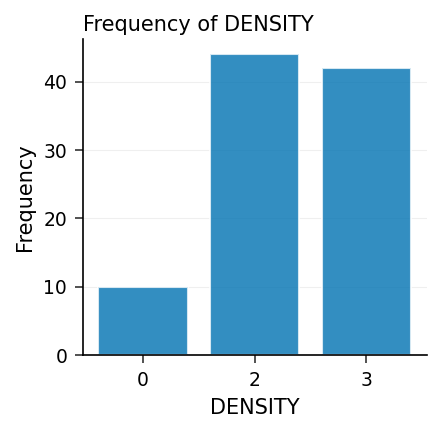

In [2]:
PROCEDIMENTO GREDUCE DADOS=zonemap out=reducedmap;
    id zone;
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=reducedmap;
    TABLES DENSITY / nocum;
    RÓTULO DENSITY="Nível de DENSITY";
    TÍTULO "Pontos de limite retidos em cada nível de DENSITY";
EXECUTAR;

## Etapa 3 — Inspecionar os níveis de densidade

A tabela de frequência mostra como o GREDUCE classificou os 96 pontos de limite:

| DENSITY | Pontos | Proporção |
|---------|--------|-------|
| 0 | 10 | 10.4% |
| 2 | 44 | 45.8% |
| 3 | 42 | 43.8% |

Apenas 10 pontos carregam o nível mais baixo (as âncoras da forma essencial), enquanto os 86 restantes se dividem entre os níveis 2 e 3. Para um nível de painel, mantemos tudo em `DENSITY <= 2`: isso retém 54 dos 96 pontos, descartando os 42 vértices de detalhe mais fino (`DENSITY=3`). O PROC MEANS abaixo confirma que o nível grosseiro mantém de 13 a 14 vértices por zona em vez dos 24 originais.

In [3]:
PROCEDIMENTO MÉDIAS DADOS=reducedmap n;
    CLASSE zone;
    ONDE DENSITY <= 2;
    VARIÁVEL x;
    RÓTULO zone="Zona" x="Coordenada X";
    TÍTULO "Vértices mantidos por zona no detalhe do painel (DENSITY <= 2)";
EXECUTAR;

                             Vértices mantidos por zona no detalhe do painel (DENSITY <= 2)                             

                                                  The MEANS Procedure

                                           Analysis Variable : X Coordenada X

        Zona              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Etapa 4 — Construir o mapa grosseiro e a resposta de desempenho por zona

Materializamos o nível do painel como `coarsemap` (`DENSITY <= 2`) para que o PROC GMAP possa desenhar o contorno reduzido diretamente. Também sintetizamos uma linha de KPI por zona — uma **taxa de entrega no prazo** e um **volume diário de pacotes** — chaveada em `zone` para que o GMAP possa colorir cada área.

In [4]:
DADOS coarsemap;
    DEFINIR reducedmap;
    ONDE DENSITY <= 2;
EXECUTAR;

DADOS zonekpi;
    CHAMAR streaminit(771);
    FAZER zone = 1 ATÉ 4;
        /* taxa no prazo centrada perto de 92%, dispersão realista */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        SAÍDA;
    FIM;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=zonekpi noobs RÓTULO;
    RÓTULO zone="Zona" ontime_rate="Taxa de Entrega no Prazo" parcels="Pacotes";
    TÍTULO "KPIs sintéticos de entrega por zona";
EXECUTAR;

                                          KPIs sintéticos de entrega por zona                                           

Zona  Taxa de Entrega no Prazo  Pacotes
   1                      92.6     4704
   2                      95.6     2932
   3                      93.4     2934
   4                      94.6     2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


As quatro taxas sintéticas de entrega no prazo ficam entre 92.6% e 95.6%, com volumes diários de pacotes de aproximadamente 2500 a 4700 unidades. A zona 2 é a de melhor desempenho com 95.6%; a zona 1 é a mais fraca com 92.6%. Estes são os valores que as bandas de cor do coroplético codificam.

## Etapa 5 — Renderizar coropléticos de detalhe completo vs. reduzido

Desenhamos o mesmo coroplético de entrega no prazo duas vezes: uma a partir do `reducedmap` completo de 96 vértices e outra a partir do `coarsemap` de 54 vértices. `MAP=` fornece os limites, `DATA=` a resposta de KPI, e ambos compartilham o ID `zone`. A instrução `CHORO` preenche cada zona por `ontime_rate` com bandas de cor `LEVELS=4` e `COUTLINE=` para bordas nítidas. Comparar os dois mapas mostra o que a redução custa visualmente.

                                        Detalhe completo: 96 vértices de limite                                         




NOTE: Option TITLE changed to Detalhe completo: 96 vértices de limite.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Taxa de Entrega no Prazo.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.41 seconds
  cpu   0.41 seconds


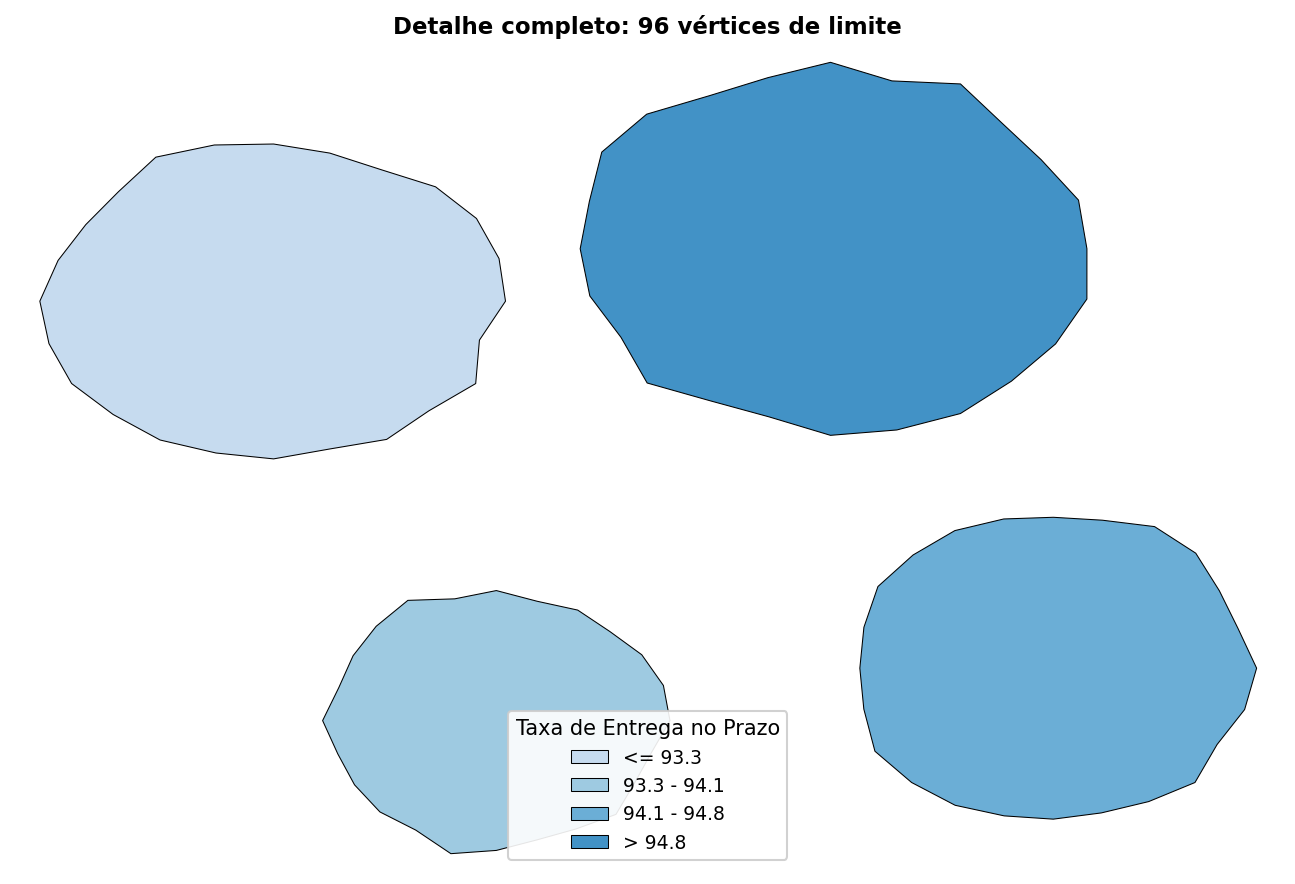

In [5]:
TÍTULO "Detalhe completo: 96 vértices de limite";
PROCEDIMENTO GMAP map=reducedmap DADOS=zonekpi;
    id zone;
    RÓTULO ontime_rate="Taxa de Entrega no Prazo";
    CHORO ontime_rate / levels=4 coutline=black;
EXECUTAR;

                                      Detalhe reduzido: 54 vértices (DENSITY <= 2)                                      




NOTE: Option TITLE changed to Detalhe reduzido: 54 vértices (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Taxa de Entrega no Prazo.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.41 seconds
  cpu   0.41 seconds


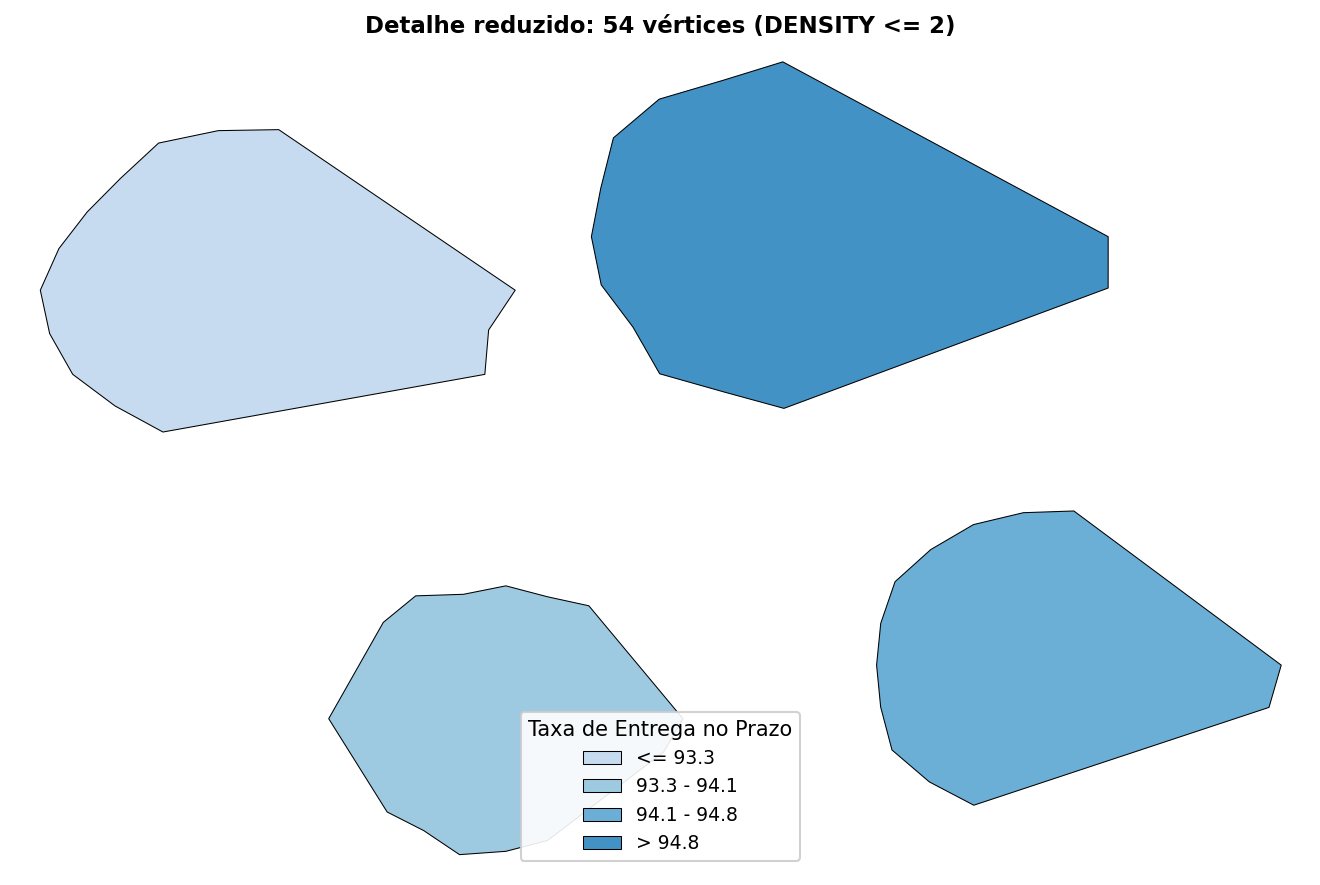

In [6]:
TÍTULO "Detalhe reduzido: 54 vértices (DENSITY <= 2)";
PROCEDIMENTO GMAP map=coarsemap DADOS=zonekpi;
    id zone;
    RÓTULO ontime_rate="Taxa de Entrega no Prazo";
    CHORO ontime_rate / levels=4 coutline=black;
EXECUTAR;

## Interpretando os resultados

O PROC GREDUCE transformou cada contorno de zona de 24 vértices em um conjunto classificado de pontos de limite (níveis 0, 2 e 3 nesta execução). Selecionar o nível `DENSITY <= 2` reduziu o mapa de 96 vértices para 54 — uma redução de 44% nos pontos que o renderizador precisa desenhar — mas os coropléticos lado a lado confirmam que as quatro zonas permanecem claramente reconhecíveis: os contornos do mapa reduzido são visivelmente mais angulares, mas cada território mantém sua posição, tamanho e banda de cor, então um operador lê o mesmo placar de qualquer forma.

Esse placar classifica as zonas por taxa de entrega no prazo: a zona 2 lidera com 95.6% (banda mais escura), as zonas 3 e 4 ficam no meio perto de 93-95%, e a zona 1 fica atrás com 92.6% (banda mais clara) — o território que um planejador investigaria primeiro por problemas de roteamento ou capacidade do depósito.

Como a redução não é destrutiva — os pontos de detalhe completo continuam existindo em `reducedmap` — o mesmo dataset suporta tanto a visão rápida do painel (`DENSITY <= 2`) quanto uma visão de impressão ou auditoria de alta resolução (`DENSITY <= 3`, ou o conjunto completo) alterando um único limiar de `WHERE`, sem necessidade de reimportar ou reduzir novamente a geometria.